Parcila #2
Santiago Aroleda
Juan Esteban Villada
Cristian Cabezas

✅ Librerías importadas
⏳ Descargando dataset desde HuggingFace...
✅ 3,002,137 filas × 10 columnas
    Time  Right Rectus femoris  Left Gluteus maximus  Left Gastrocnemius medialis  Left Semitendinosus  Left Biceps femoris caput longus  Right Vastus medialis  Right Tibialis anterior  Left Gastrocnemius lateralis  Target
0  0.000             -0.000264             -0.000015                     0.000344             0.000108                          0.000182               0.000401                 0.000267                     -0.000236       0
1  0.001             -0.001002             -0.000045                     0.001342             0.000429                          0.000712               0.002234                 0.001234                     -0.001108       0
2  0.002             -0.002173             -0.000034                     0.002944             0.001133                          0.001692               0.007634                 0.003457                     -0.003277       0
Distribuci

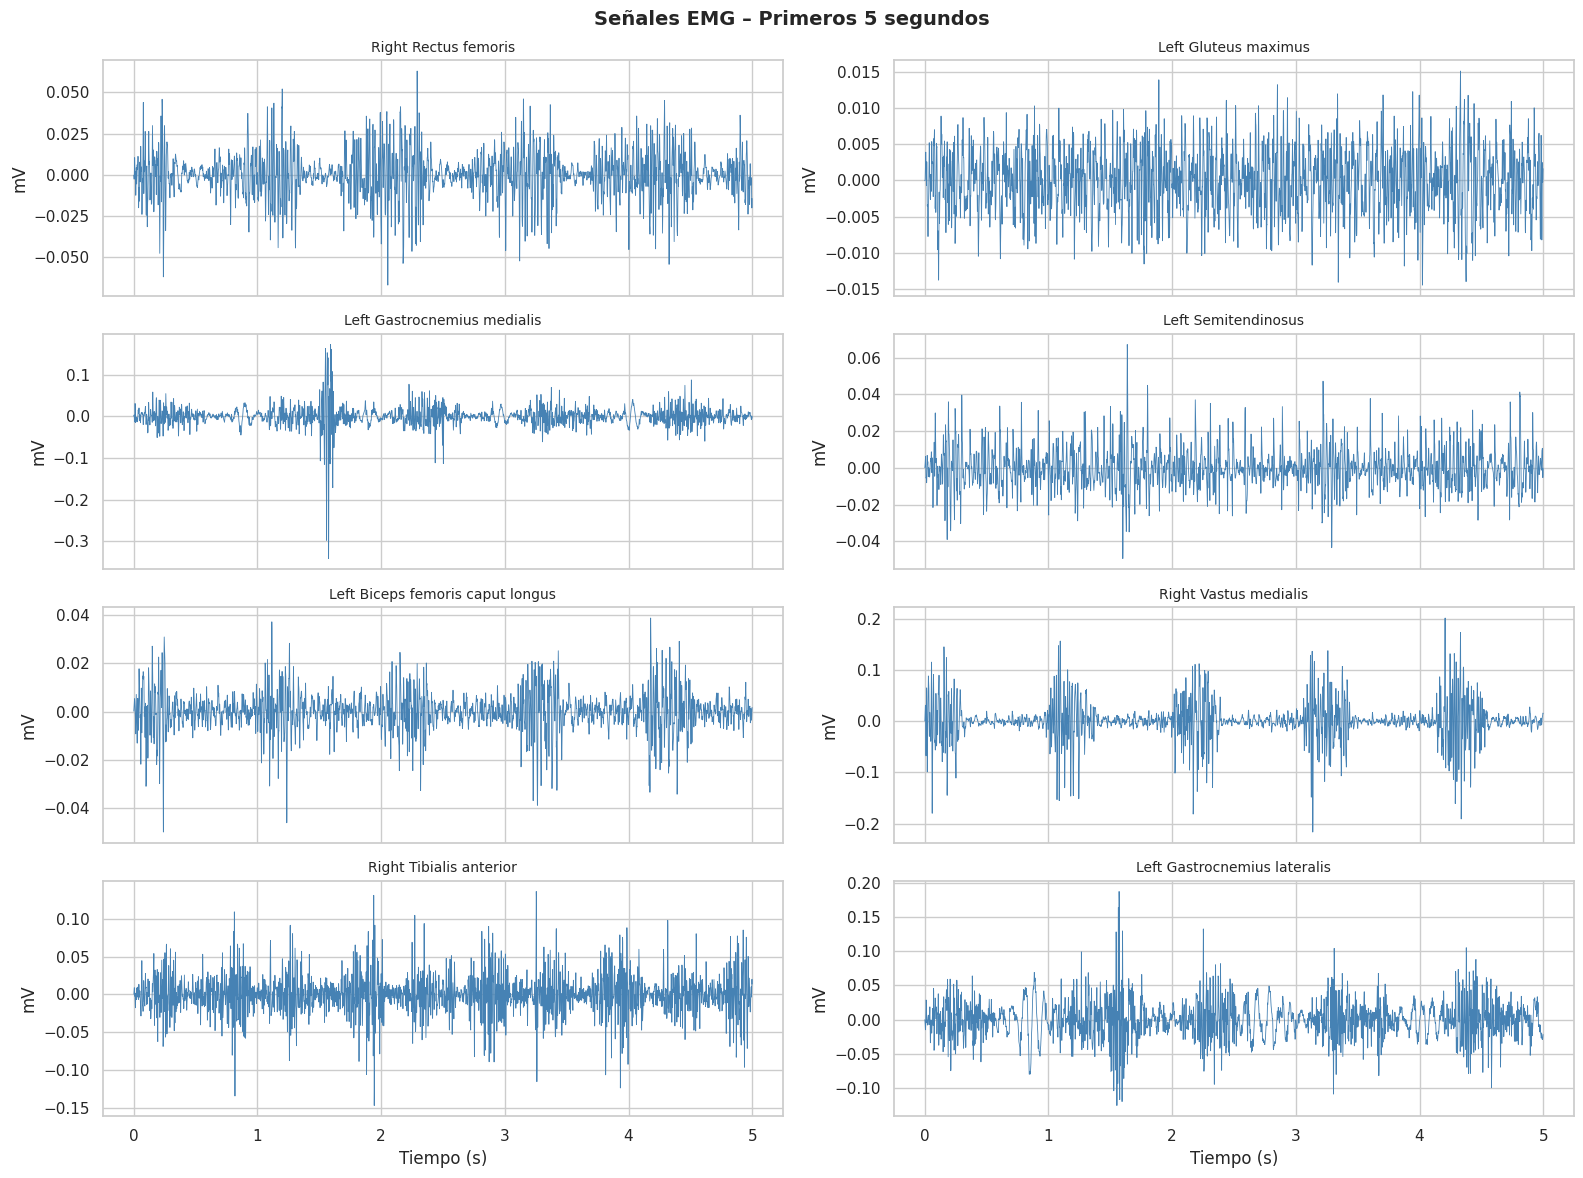

Total de muestras: 3,002,137
Ventanas de 1 segundo: 3002
⏳ Extrayendo características...
✅ Nuevo dataset: 3002 filas × 57 columnas
     M1_rms    M1_var  M1_zcr    M1_mav    M1_pot  M1_f_media  M1_f_mediana  \
0  0.011706  0.000137     123  0.008125  0.000037   54.570691      50.78125   
1  0.014023  0.000197     111  0.010118  0.000045   55.855871      54.68750   
2  0.014820  0.000220     121  0.010151  0.000051   54.184530      46.87500   
3  0.013817  0.000191     121  0.009894  0.000053   57.536069      46.87500   
4  0.013326  0.000177     122  0.009676  0.000045   58.618607      46.87500   

     M2_rms    M2_var  M2_zcr  ...  M7_f_media  M7_f_mediana    M8_rms  \
0  0.003989  0.000016     122  ...   90.848126      93.75000  0.025655   
1  0.004223  0.000018     120  ...   86.074641      82.03125  0.031409   
2  0.004209  0.000018     126  ...   85.845131      85.93750  0.026209   
3  0.004374  0.000019     115  ...   86.521454      85.93750  0.021673   
4  0.004641  0.000022   

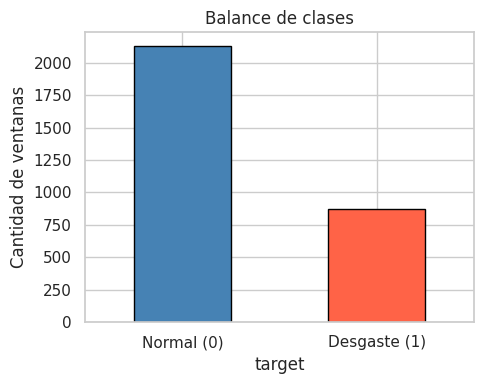

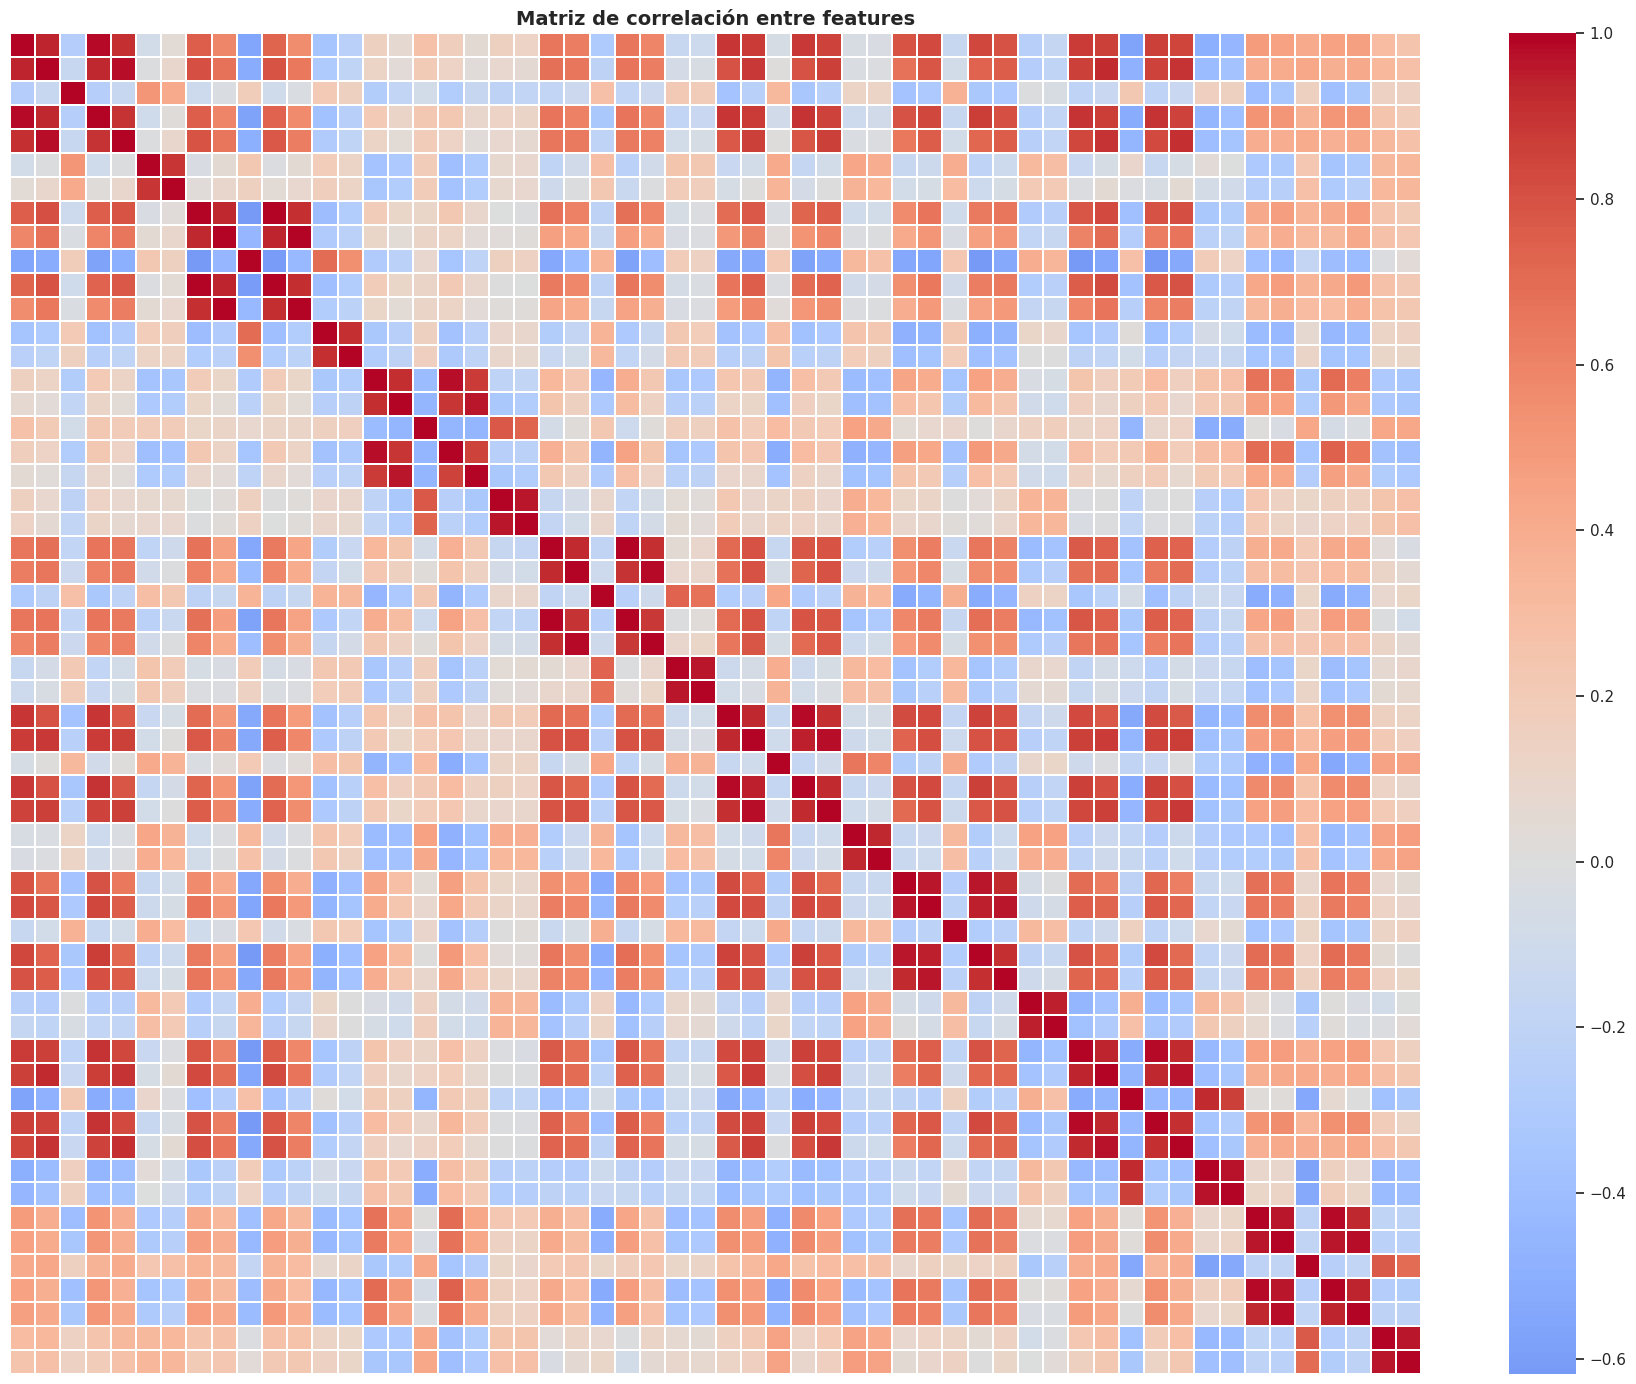

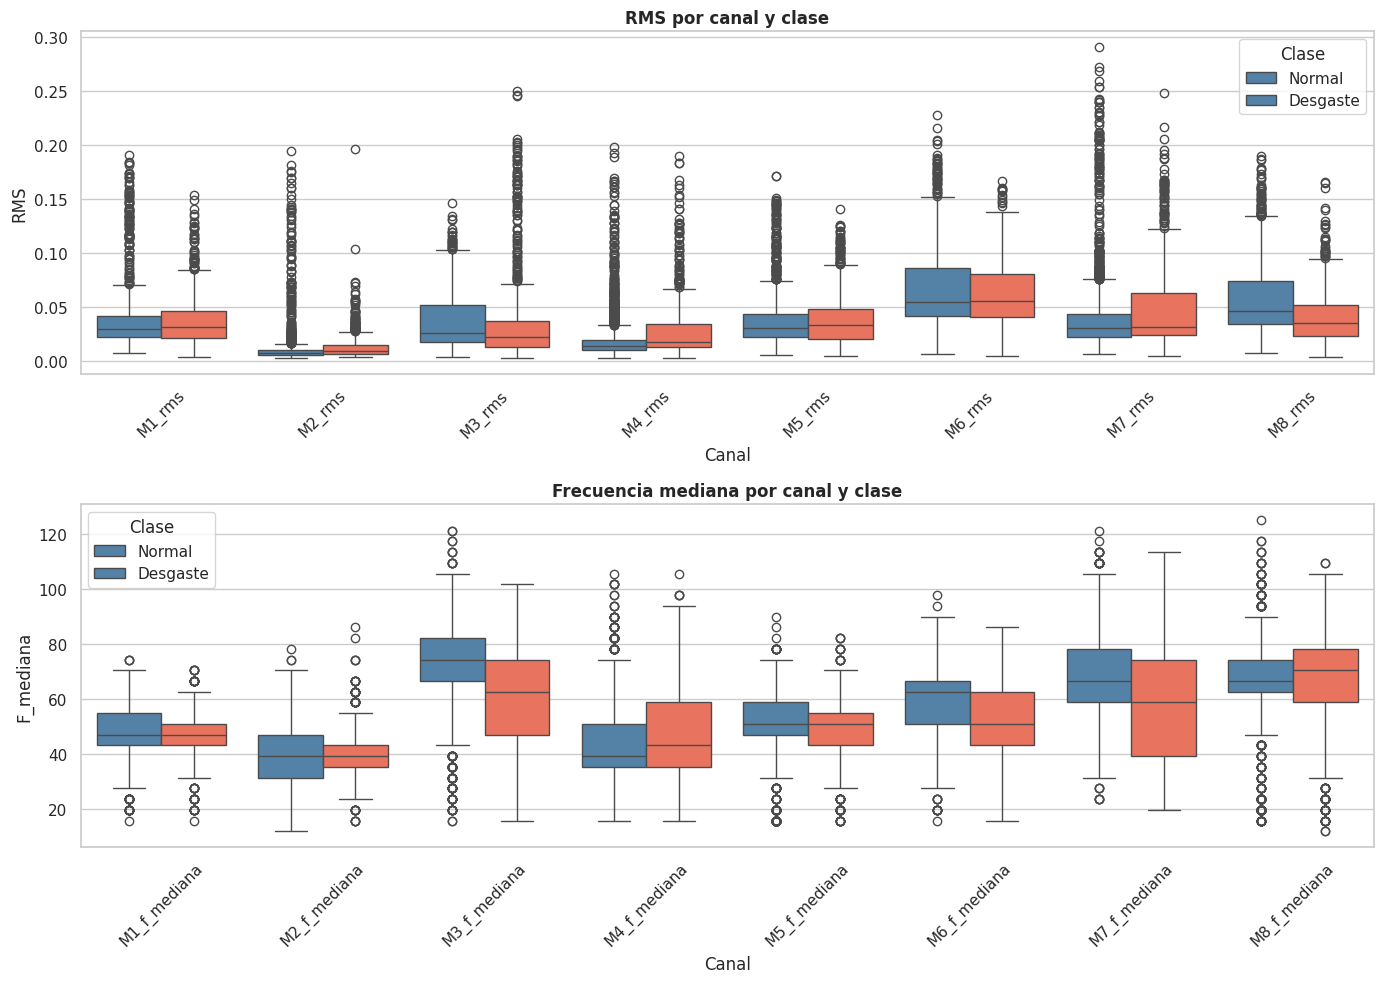

Train: 2101 muestras
Val:   450 muestras
Test:  451 muestras
✅ Datos preprocesados
⏳ Entrenando modelos...
  → kNN
  → Decision Tree
  → Random Forest
  → Gradient Boosting
  → DNN (MLP)
✅ Modelos entrenados
=== Tabla completa de métricas ===
                         Accuracy  Precision  Recall      F1
Modelo            Split                                     
kNN               Train    0.8924     0.8814  0.7288  0.7979
                  Val      0.8333     0.7593  0.6260  0.6862
                  Test     0.8758     0.8099  0.7481  0.7778
Decision Tree     Train    1.0000     1.0000  1.0000  1.0000
                  Val      0.8022     0.6641  0.6489  0.6564
                  Test     0.8160     0.6765  0.7023  0.6891
Random Forest     Train    1.0000     1.0000  1.0000  1.0000
                  Val      0.8733     0.8033  0.7481  0.7747
                  Test     0.8936     0.8547  0.7634  0.8065
Gradient Boosting Train    0.9291     0.9461  0.8023  0.8683
                  Val    

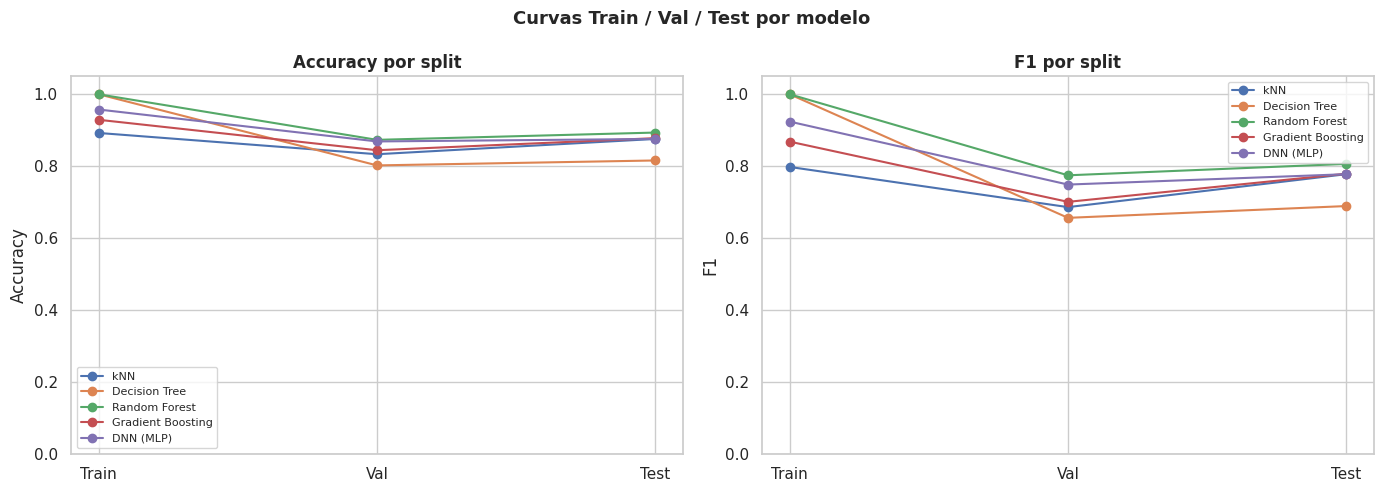

Mejor modelo en validación (F1): Random Forest
⏳ Random Search para Random Forest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
✅ Mejores hiperparámetros: {'n_estimators': 300, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 30}
   F1 en CV: 0.7611
=== Evaluación Final sobre X_test ===
              precision    recall  f1-score   support

      Normal       0.92      0.94      0.93       320
    Desgaste       0.85      0.80      0.82       131

    accuracy                           0.90       451
   macro avg       0.88      0.87      0.88       451
weighted avg       0.90      0.90      0.90       451

 Accuracy  Precision  Recall  F1-Score
   0.9002     0.8468  0.8015    0.8235


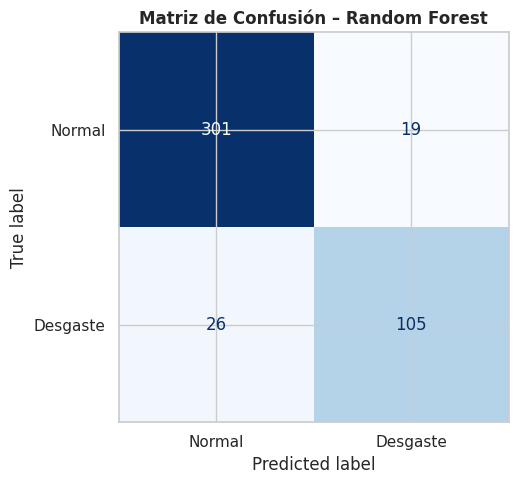

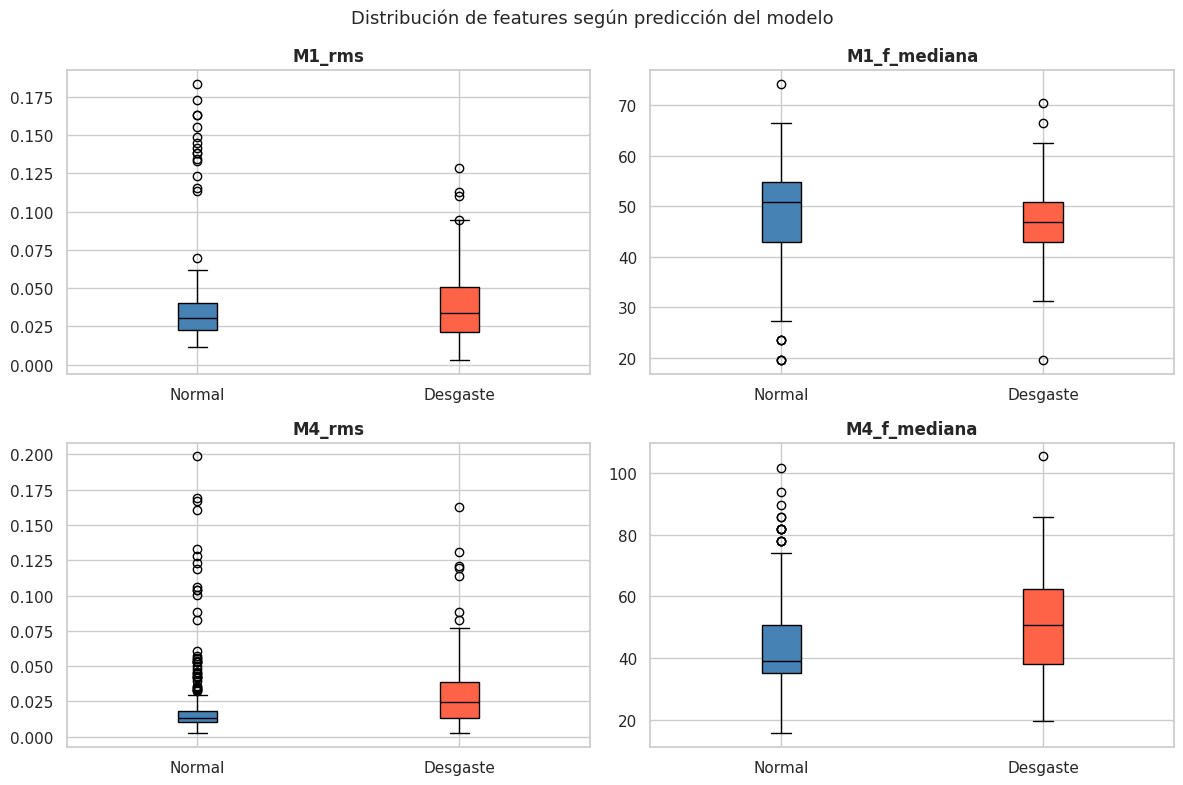

Predicción para muestra artificial: Condición normal 🟢 (clase 0)


'\nUna señal con frecuencia dominante baja (~45 Hz) y amplitud alta debería clasificarse\ncomo desgaste. Si el modelo lo detecta correctamente, confirma que aprendió el patrón\nfisiológico real de la fatiga muscular EMG y no simplemente memorizó los datos.\n'

In [5]:

# WORKSHOP 2 – PROBLEMA 1: CLASIFICACIÓN
# Detección de Fatiga Muscular en Ciclismo


!pip install datasets scikit-learn scipy matplotlib seaborn pandas numpy -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
print("✅ Librerías importadas")


# ── Carga del dataset ────────────────────────────────────────
from datasets import load_dataset

print("⏳ Descargando dataset desde HuggingFace...")
ds = load_dataset("YominE/Muscle_Fatigue_Cycling")
df = ds["train"].to_pandas()

print(f"✅ {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(df.head(3).to_string())


# ── Análisis preliminar: tipos de variables y binarización ───
"""
Variables:
- Time: numérica continua — NO se usa (correlación lineal directa con el target → trampa).
- 8 canales EMG: numéricas continuas (mV), una por músculo de la pierna dominante.
- Target: ordinal (0, 1, 2) → se binariza a (0 = normal, 1 = desgaste muscular).

Frecuencia de muestreo: 1000 Hz (1000 filas = 1 segundo de señal).
"""

# Renombrar canales para evitar espacios en los nombres de columnas
channel_aliases = {
    'Right Rectus femoris':             'M1',
    'Left Gluteus maximus':             'M2',
    'Left Gastrocnemius medialis':      'M3',
    'Left Semitendinosus':              'M4',
    'Left Biceps femoris caput longus': 'M5',
    'Right Vastus medialis':            'M6',
    'Right Tibialis anterior':          'M7',
    'Left Gastrocnemius lateralis':     'M8',
}
df.rename(columns=channel_aliases, inplace=True)
channels = list(channel_aliases.values())

print("Distribución original del target:")
print(df['Target'].value_counts())

df['Target'] = df['Target'].replace(2, 1)

print("\nDistribución binarizada:")
print(df['Target'].value_counts())
print(f"  0 = Condición normal:  {(df['Target']==0).sum():,} muestras")
print(f"  1 = Desgaste muscular: {(df['Target']==1).sum():,} muestras")


# ── Visualización de señales crudas ──────────────────────────
"""
Se grafican los primeros 5 segundos de cada canal para identificar visualmente
las características de las señales EMG y detectar posibles artefactos.
"""
muestra = df.iloc[:5000]

fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()
muscle_labels = list(channel_aliases.keys())

for i, (ch, label) in enumerate(zip(channels, muscle_labels)):
    axes[i].plot(muestra['Time'], muestra[ch], linewidth=0.6, color='steelblue')
    axes[i].set_title(label, fontsize=10)
    axes[i].set_ylabel('mV')

axes[-1].set_xlabel('Tiempo (s)')
axes[-2].set_xlabel('Tiempo (s)')
fig.suptitle('Señales EMG – Primeros 5 segundos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

"""
Conclusiones:
- Las señales son oscilaciones rápidas centradas en cero, típicas de actividad neuromuscular.
- Hay diferencias de amplitud entre músculos, reflejando distintos niveles de activación.
- No es posible distinguir fatiga de condición normal a simple vista en la señal cruda,
  lo que justifica la extracción de características representativas.
"""


# ── Extracción de características (Feature Engineering) ──────
"""
Se dividen las señales en ventanas no solapadas de 1 segundo (1000 muestras cada una).
Por cada ventana y canal se extraen 7 características → 56 features por ventana.

Dominio del tiempo:
- RMS: raíz del promedio cuadrático; indica la energía de contracción muscular.
- Varianza: dispersión de la amplitud; tiende a aumentar con la fatiga.
- ZCR (Zero Crossing Rate): número de cruces por cero; proxy de la frecuencia dominante.
- MAV (Mean Absolute Value): promedio del valor absoluto; mide el nivel de activación.

Dominio de la frecuencia (método de Welch):
- Potencia total: energía espectral total de la ventana.
- Frecuencia media: promedio ponderado de frecuencias; disminuye con la fatiga muscular.
- Frecuencia mediana: divide la potencia espectral en dos mitades iguales;
  es el indicador más utilizado clínicamente para detectar fatiga EMG.
"""

fs = 1000
window_size = fs  # 1 seg = 1000 muestras

def extraer_caracteristicas(ventana, fs=1000):
    rms          = np.sqrt(np.mean(ventana**2))
    varianza     = np.var(ventana)
    zcr          = np.sum(np.diff(np.sign(ventana)) != 0)
    mav          = np.mean(np.abs(ventana))
    freqs, psd   = welch(ventana, fs=fs, nperseg=min(256, len(ventana)))
    pot_total    = np.sum(psd)
    frec_media   = np.sum(freqs * psd) / (np.sum(psd) + 1e-10)
    pot_acum     = np.cumsum(psd)
    idx_median   = np.searchsorted(pot_acum, pot_acum[-1] / 2)
    frec_mediana = freqs[min(idx_median, len(freqs) - 1)]
    return [rms, varianza, zcr, mav, pot_total, frec_media, frec_mediana]

n_windows  = len(df) // window_size
feat_names = ['rms', 'var', 'zcr', 'mav', 'pot', 'f_media', 'f_mediana']

print(f"Total de muestras: {len(df):,}")
print(f"Ventanas de 1 segundo: {n_windows}")
print("⏳ Extrayendo características...")

filas = []
for i in range(n_windows):
    inicio     = i * window_size
    fin        = inicio + window_size
    ventana_df = df.iloc[inicio:fin]
    fila       = {}
    for canal in channels:
        ventana = ventana_df[canal].values
        feats   = extraer_caracteristicas(ventana, fs=fs)
        for nombre, valor in zip(feat_names, feats):
            fila[f'{canal}_{nombre}'] = valor
    fila['target'] = ventana_df['Target'].mode()[0]
    filas.append(fila)

nuevo_df = pd.DataFrame(filas)
print(f"✅ Nuevo dataset: {nuevo_df.shape[0]} filas × {nuevo_df.shape[1]} columnas")
print(nuevo_df.head())


# ── EDA: Estadísticos descriptivos ───────────────────────────
print("=== Estadísticos descriptivos ===")
print(nuevo_df.describe().T.round(4).to_string())


# ── EDA: Balance de clases ───────────────────────────────────
print("\n=== Balance de clases ===")
print(nuevo_df['target'].value_counts())

fig, ax = plt.subplots(figsize=(5, 4))
nuevo_df['target'].value_counts().plot(
    kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_xticklabels(['Normal (0)', 'Desgaste (1)'], rotation=0)
ax.set_title('Balance de clases')
ax.set_ylabel('Cantidad de ventanas')
plt.tight_layout()
plt.show()

"""
Si existe desbalance significativo, accuracy puede ser engañosa.
Se priorizarán F1-score, Recall y Precision para la evaluación.
"""


# ── EDA: Correlaciones entre features ────────────────────────
features_cols = [c for c in nuevo_df.columns if c != 'target']
corr_matrix   = nuevo_df[features_cols].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            linewidths=0.3, xticklabels=False, yticklabels=False)
plt.title('Matriz de correlación entre features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

"""
Features del mismo tipo (ej. RMS de todos los canales) tienden a correlacionarse
porque los músculos trabajan en conjunto durante el pedaleo.
Esto motiva el uso de modelos robustos a la multicolinealidad como Random Forest.
"""


# ── EDA: Separabilidad por clase ─────────────────────────────
rms_cols  = [f'{ch}_rms'       for ch in channels]
fmed_cols = [f'{ch}_f_mediana' for ch in channels]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

df_rms = nuevo_df[rms_cols + ['target']].melt(
    id_vars='target', var_name='Canal', value_name='RMS')
sns.boxplot(data=df_rms, x='Canal', y='RMS', hue='target',
            palette={0: 'steelblue', 1: 'tomato'}, ax=axes[0])
axes[0].set_title('RMS por canal y clase', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Clase', labels=['Normal', 'Desgaste'])

df_fmed = nuevo_df[fmed_cols + ['target']].melt(
    id_vars='target', var_name='Canal', value_name='F_mediana')
sns.boxplot(data=df_fmed, x='Canal', y='F_mediana', hue='target',
            palette={0: 'steelblue', 1: 'tomato'}, ax=axes[1])
axes[1].set_title('Frecuencia mediana por canal y clase', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Clase', labels=['Normal', 'Desgaste'])

plt.tight_layout()
plt.show()

"""
- RMS mayor en desgaste indica mayor activación o compensación muscular durante la fatiga.
- La disminución de la frecuencia mediana con la fatiga es un fenómeno fisiológico
  bien documentado: al fatigarse, el músculo recluta fibras de contracción lenta
  con frecuencias de disparo más bajas, desplazando el espectro hacia frecuencias menores.
"""


# ── Procesamiento: Pipeline y Split 70/15/15 ─────────────────
X = nuevo_df.drop(columns=['target'])
y = nuevo_df['target']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Val:   {X_val.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

# Pipeline con imputación de nulos y estandarización
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler())
])

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)
print("✅ Datos preprocesados")

"""
Split 70/15/15: el conjunto de validación se usa para selección y ajuste de hiperparámetros.
El conjunto de test se reserva exclusivamente para la evaluación final del modelo elegido.
La estandarización se ajusta solo sobre train para evitar data leakage.
"""


# ── Entrenamiento y comparación de modelos ───────────────────
def evaluar_modelo(modelo, X_tr, y_tr, X_v, y_v, X_te, y_te):
    modelo.fit(X_tr, y_tr)
    resultados = {}
    for nombre_split, X_sp, y_sp in [('Train', X_tr, y_tr),
                                      ('Val',   X_v,  y_v),
                                      ('Test',  X_te, y_te)]:
        pred = modelo.predict(X_sp)
        resultados[nombre_split] = {
            'Accuracy':  accuracy_score(y_sp, pred),
            'Precision': precision_score(y_sp, pred, zero_division=0),
            'Recall':    recall_score(y_sp, pred, zero_division=0),
            'F1':        f1_score(y_sp, pred, zero_division=0),
        }
    return modelo, resultados

modelos = {
    'kNN':               KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':     DecisionTreeClassifier(random_state=42),
    'Random Forest':     RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'DNN (MLP)':         MLPClassifier(
                             hidden_layer_sizes=(256, 128, 64),
                             activation='relu',
                             max_iter=300,
                             early_stopping=True,
                             validation_fraction=0.1,
                             alpha=0.001,
                             random_state=42
                         ),
}

todos_resultados   = {}
modelos_entrenados = {}

print("⏳ Entrenando modelos...")
for nombre, modelo in modelos.items():
    print(f"  → {nombre}")
    modelo_fit, res = evaluar_modelo(
        modelo, X_train_proc, y_train, X_val_proc, y_val, X_test_proc, y_test)
    todos_resultados[nombre]   = res
    modelos_entrenados[nombre] = modelo_fit
print("✅ Modelos entrenados")


# ── Tabla comparativa de métricas ────────────────────────────
rows = []
for nombre, res in todos_resultados.items():
    for split, metricas in res.items():
        row = {'Modelo': nombre, 'Split': split}
        row.update(metricas)
        rows.append(row)

tabla = pd.DataFrame(rows)
print("=== Tabla completa de métricas ===")
print(tabla.set_index(['Modelo', 'Split']).round(4).to_string())


# ── Curvas Train / Val / Test ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metrica in zip(axes, ['Accuracy', 'F1']):
    for nombre, res in todos_resultados.items():
        vals = [res['Train'][metrica], res['Val'][metrica], res['Test'][metrica]]
        ax.plot(['Train', 'Val', 'Test'], vals, marker='o', label=nombre)
    ax.set_title(f'{metrica} por split', fontweight='bold')
    ax.set_ylabel(metrica)
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.05)

plt.suptitle('Curvas Train / Val / Test por modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

"""
Interpretación de las curvas:
- Train >> Val/Test con brecha grande → Overfitting.
- Train ≈ Val ≈ Test y ambos bajos  → Underfitting.
- El modelo ideal tiene alto desempeño en los tres splits con brecha mínima.
"""


# ── Ajuste de hiperparámetros con Random Search ──────────────
mejor_nombre = max(todos_resultados, key=lambda n: todos_resultados[n]['Val']['F1'])
print(f"Mejor modelo en validación (F1): {mejor_nombre}")

param_grids = {
    'Random Forest': {
        'n_estimators':      [100, 200, 300],
        'max_depth':         [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'max_features':      ['sqrt', 'log2'],
    },
    'Gradient Boosting': {
        'n_estimators':  [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth':     [3, 5, 7],
        'subsample':     [0.7, 0.9, 1.0],
    },
    'kNN': {
        'n_neighbors': [3, 5, 7, 11, 15],
        'weights':     ['uniform', 'distance'],
        'metric':      ['euclidean', 'manhattan'],
    },
    'Decision Tree': {
        'max_depth':         [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'criterion':         ['gini', 'entropy'],
    },
    'DNN (MLP)': {
        'hidden_layer_sizes': [(128, 64), (256, 128, 64), (512, 256, 128)],
        'alpha':              [0.0001, 0.001, 0.01],
        'learning_rate_init': [0.001, 0.01],
    },
}

base_estimators = {
    'Random Forest':     RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'kNN':               KNeighborsClassifier(),
    'Decision Tree':     DecisionTreeClassifier(random_state=42),
    'DNN (MLP)':         MLPClassifier(max_iter=300, early_stopping=True, random_state=42),
}

if mejor_nombre in param_grids:
    print(f"⏳ Random Search para {mejor_nombre}...")
    rs = RandomizedSearchCV(
        base_estimators[mejor_nombre],
        param_distributions=param_grids[mejor_nombre],
        n_iter=20, cv=3, scoring='f1',
        random_state=42, n_jobs=-1, verbose=1
    )
    rs.fit(X_train_proc, y_train)
    print(f"✅ Mejores hiperparámetros: {rs.best_params_}")
    print(f"   F1 en CV: {rs.best_score_:.4f}")
    mejor_modelo_tuned = rs.best_estimator_
else:
    mejor_modelo_tuned = modelos_entrenados[mejor_nombre]


# ── Evaluación final: reentrenar con Train + Val ─────────────
X_trainval = np.vstack([X_train_proc, X_val_proc])
y_trainval  = pd.concat([y_train, y_val]).reset_index(drop=True)

mejor_modelo_tuned.fit(X_trainval, y_trainval)
y_pred_final = mejor_modelo_tuned.predict(X_test_proc)

print("=== Evaluación Final sobre X_test ===")
print(classification_report(y_test, y_pred_final,
                             target_names=['Normal', 'Desgaste']))

metricas_finales = {
    'Accuracy':  accuracy_score(y_test, y_pred_final),
    'Precision': precision_score(y_test, y_pred_final, zero_division=0),
    'Recall':    recall_score(y_test, y_pred_final, zero_division=0),
    'F1-Score':  f1_score(y_test, y_pred_final, zero_division=0),
}
print(pd.DataFrame([metricas_finales]).round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_final),
    display_labels=['Normal', 'Desgaste']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de Confusión – {mejor_nombre}', fontweight='bold')
plt.tight_layout()
plt.show()


# ── Boxplots finales por predicción ──────────────────────────
X_test_df         = X_test.copy()
X_test_df['pred'] = y_pred_final.astype(int)
feat_rep          = ['M1_rms', 'M1_f_mediana', 'M4_rms', 'M4_f_mediana']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, feat in zip(axes, feat_rep):
    if feat in X_test_df.columns:
        grupo0 = X_test_df.loc[X_test_df['pred'] == 0, feat]
        grupo1 = X_test_df.loc[X_test_df['pred'] == 1, feat]
        bp = ax.boxplot([grupo0, grupo1], patch_artist=True,
                        medianprops=dict(color='black'))
        for patch, color in zip(bp['boxes'], ['steelblue', 'tomato']):
            patch.set_facecolor(color)
        ax.set_xticks([1, 2])
        ax.set_xticklabels(['Normal', 'Desgaste'])
        ax.set_title(feat, fontweight='bold')

plt.suptitle('Distribución de features según predicción del modelo', fontsize=13)
plt.tight_layout()
plt.show()

"""
Se espera que la frecuencia mediana sea menor en las muestras clasificadas como desgaste
y que el RMS sea mayor, consistent con los patrones fisiológicos conocidos de la fatiga EMG.
Si el modelo refleja estos patrones, valida que aprendió representaciones fisiológicamente
coherentes y no simplemente memorizó los datos de entrenamiento.

Posibles mejoras: features de entropía espectral, wavelets, modelos secuenciales (LSTM/GRU),
técnicas de balanceo de clases (SMOTE), o ensambles más avanzados.
"""


# ── Prueba con muestra artificial ────────────────────────────
"""
Se genera una señal EMG sintética que simula un músculo fatigado:
frecuencia dominante baja (~45 Hz) y amplitud alta.
"""
def generar_señal_emg(freq_dom=80, amplitud=0.1, fs=1000):
    t      = np.linspace(0, 1, fs)
    señal  = amplitud * np.sin(2 * np.pi * freq_dom * t)
    señal += 0.02 * np.random.randn(fs)
    return señal

np.random.seed(99)
fila_artificial = {}
for canal in channels:
    seg   = generar_señal_emg(freq_dom=45, amplitud=0.15)
    feats = extraer_caracteristicas(seg, fs=1000)
    for nombre, valor in zip(feat_names, feats):
        fila_artificial[f'{canal}_{nombre}'] = valor

X_art      = pd.DataFrame([fila_artificial])
X_art_proc = preprocessor.transform(X_art)
pred_art   = mejor_modelo_tuned.predict(X_art_proc)[0]
label      = "Desgaste muscular 🔴" if pred_art == 1 else "Condición normal 🟢"

print(f"Predicción para muestra artificial: {label} (clase {pred_art})")

"""
Una señal con frecuencia dominante baja (~45 Hz) y amplitud alta debería clasificarse
como desgaste. Si el modelo lo detecta correctamente, confirma que aprendió el patrón
fisiológico real de la fatiga muscular EMG y no simplemente memorizó los datos.
"""

TensorFlow: 2.19.0
GPU disponible: []
⏳ Descargando UTKFace desde HuggingFace...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/362M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/522M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10135 [00:00<?, ? examples/s]

✅ Dataset cargado: 10135 muestras
Columnas disponibles: ['image', 'age', 'gender', 'race']
                                               image  age  gender  race
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...  100       1     0
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...  100       1     2
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...  100       1     2
3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...  101       1     2
4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...   10       0     0
Shape: (10135, 4)

Rango de edades: [1, 110] años


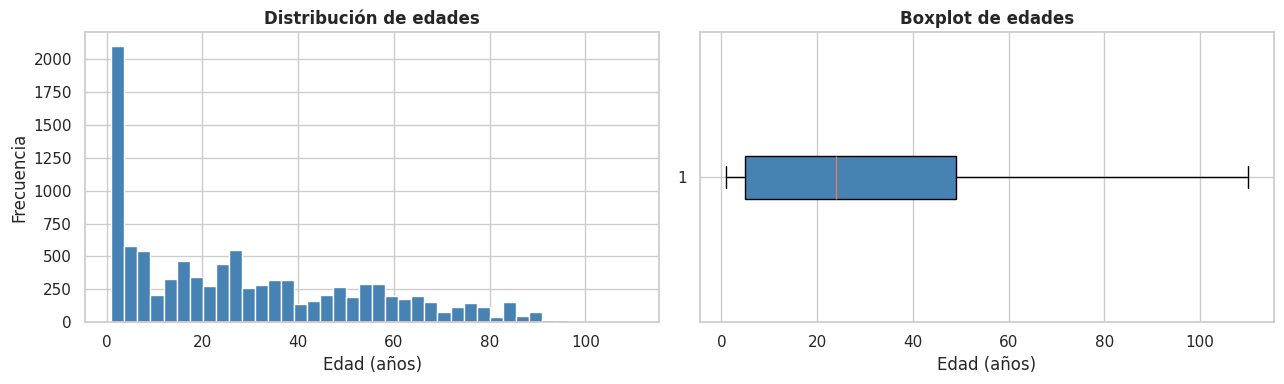

=== Estadísticos descriptivos de la edad ===
count    10135.00
mean        28.88
std         24.97
min          1.00
25%          5.00
50%         24.00
75%         49.00
max        110.00
Name: age, dtype: float64


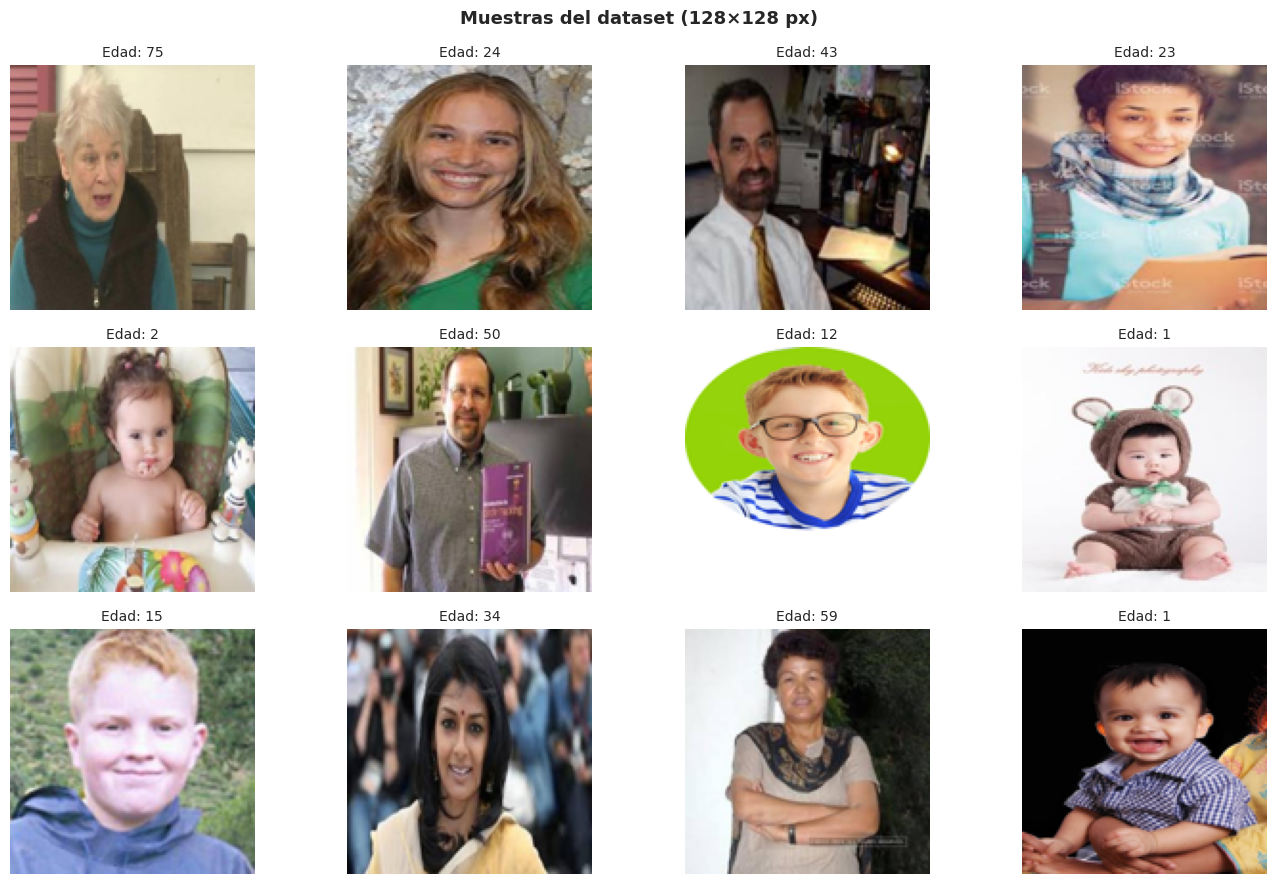

⏳ Cargando imágenes en memoria...
✅ 10135 imágenes listas — Shape: (10135, 128, 128, 3)
   Rango de edades: [1, 110] años
Train: 7094 | Val: 1520 | Test: 1521
✅ Data Augmentation configurado


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 686,273 (2.62 MB)

 Trainable params: 685,313 (2.61 MB)

 Non-trainable params: 960 (3.75 KB)

⏳ Entrenando CNN...
Epoch 1/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 490s 2s/step - loss: 20.9352 - mae: 21.3611 - val_loss: 20.6137 - val_mae: 21.0407 - learning_rate: 0.0010
Epoch 2/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 514s 2s/step - loss: 20.9548 - mae: 21.3802 - val_loss: 19.8831 - val_mae: 20.3083 - learning_rate: 0.0010
Epoch 3/60
176/222 ━━━━━━━━━━━━━━━━━━━━ 1:34 2s/step - loss: 21.0373 - mae: 21.4635

In [ ]:

# WORKSHOP 2 – PROBLEMA 2: REGRESIÓN
# Estimación de Edad a partir de Imágenes Faciales (CNN)


!pip install datasets tensorflow matplotlib seaborn pandas numpy scikit-learn -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

print(f"TensorFlow: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")


# ── Descarga del dataset UTKFace ─────────────────────────────
"""
Se usa el dataset UTKFace (Subh775/UTKFace_demographics_V1), disponible
públicamente en HuggingFace sin necesidad de cuenta ni credenciales.
Contiene más de 20,000 imágenes faciales etiquetadas con edad (0–116 años),
género y etnicidad. Es ampliamente usado en investigación académica para
estimación de edad facial, equivalente al dataset del enunciado.
"""
from datasets import load_dataset
from PIL import Image

print("⏳ Descargando UTKFace desde HuggingFace...")
ds = load_dataset("Subh775/UTKFace_demographics_V1", split="train")
print(f"✅ Dataset cargado: {len(ds)} muestras")
print("Columnas disponibles:", ds.column_names)

AGE_COL = 'age'


# ── Análisis preliminar del problema ─────────────────────────
"""
¿Por qué es regresión?
El target (edad) es una variable numérica continua. Predecir un valor numérico
en lugar de una categoría define el problema como regresión.

Variable objetivo: edad del sujeto en años (0–116).

Características de entrada: imágenes RGB de rostros.
- Dimensiones variables → se redimensionan a 128×128 px.
- Espacio de color: RGB (3 canales).
- Valores de píxeles 0–255 → normalizados a [0, 1].

Protocolo de adquisición:
UTKFace es un dataset público recopilado de fuentes diversas de internet,
anotado con edad, género y etnicidad. Presenta alta variabilidad en iluminación,
pose y expresión facial, lo que lo hace representativo del mundo real.
La edad fue estimada mediante el algoritmo DEX y verificada por anotadores humanos.
"""

df_meta = ds.to_pandas()
print(df_meta.head())
print("Shape:", df_meta.shape)
print(f"\nRango de edades: [{df_meta[AGE_COL].min()}, {df_meta[AGE_COL].max()}] años")


# ── EDA: Distribución de edades ──────────────────────────────
ages = df_meta[AGE_COL].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(ages, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de edades', fontweight='bold')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Frecuencia')

bp = axes[1].boxplot(ages, vert=False, patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
axes[1].set_title('Boxplot de edades', fontweight='bold')
axes[1].set_xlabel('Edad (años)')

plt.tight_layout()
plt.show()

print("=== Estadísticos descriptivos de la edad ===")
print(ages.describe().round(2))

"""
Interpretación:
- La distribución de UTKFace está sesgada hacia adultos jóvenes (20–40 años),
  lo que puede generar mayor error en edades extremas (bebés y adultos mayores).
- Una desviación estándar alta indica amplia variabilidad y mayor dificultad.
- El desbalance puede mitigarse con pérdidas ponderadas por rango de edad o
  data augmentation focalizado en grupos subrepresentados.
"""


# ── EDA: Visualización de muestras ───────────────────────────
indices = np.random.choice(len(ds), 12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
axes = axes.flatten()

for ax, idx in zip(axes, indices):
    sample = ds[int(idx)]
    img    = sample['image'].resize((128, 128))
    edad   = sample[AGE_COL]
    ax.imshow(img)
    ax.set_title(f"Edad: {int(edad)}", fontsize=10)
    ax.axis('off')

plt.suptitle('Muestras del dataset (128×128 px)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

"""
Interpretación:
- Se observa variabilidad en iluminación, pose y etnicidad: positivo para generalización.
- Imágenes ya centradas en el rostro (cropped), lo que facilita el aprendizaje de la CNN.
- Se aplica data augmentation para mejorar la robustez frente a variaciones de captura.
"""


# ── Carga y normalización de imágenes ────────────────────────
IMG_SIZE   = 128
BATCH_SIZE = 32

print("⏳ Cargando imágenes en memoria...")
imagenes  = []
etiquetas = []

for sample in ds:
    try:
        img = sample['image'].convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        arr = np.array(img, dtype='float32') / 255.0
        imagenes.append(arr)
        etiquetas.append(float(sample[AGE_COL]))
    except Exception:
        continue

X = np.array(imagenes,  dtype='float32')
y = np.array(etiquetas, dtype='float32')

print(f"✅ {len(X)} imágenes listas — Shape: {X.shape}")
print(f"   Rango de edades: [{y.min():.0f}, {y.max():.0f}] años")


# ── Split 70 / 15 / 15 ───────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

"""
Split 70/15/15: el conjunto de validación se usa para monitoreo durante el
entrenamiento y early stopping. El de test se reserva exclusivamente para
la evaluación final. La normalización [0,1] se aplicó en la carga de imágenes.
"""


# ── Data Augmentation ────────────────────────────────────────
"""
Justificación: las imágenes faciales presentan variación en orientación horizontal,
brillo y escala según las condiciones de captura.
El augmentation mejora la robustez del modelo y reduce el overfitting sin necesidad
de recolectar más datos.
"""
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomBrightness(0.10),
], name="augmentation")

print("✅ Data Augmentation configurado")


# ── Arquitectura CNN para Regresión ──────────────────────────
"""
Arquitectura:
- 4 bloques Conv2D + BatchNormalization + MaxPooling para extracción jerárquica de features.
- GlobalAveragePooling2D en lugar de Flatten: reduce parámetros y mejora generalización.
- 3 capas Dense con Dropout progresivo y regularización L2.
- Salida: 1 neurona con activación lineal (regresión).

Función de pérdida: Huber Loss — robusta a valores atípicos de edad (outliers).
Métrica de monitoreo: MAE (más interpretable en años que el RMSE).
"""

def construir_cnn(img_size=IMG_SIZE):
    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = data_augmentation(inputs)

    for filtros in [32, 64, 128, 256]:
        x = layers.Conv2D(filtros, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='linear')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.Huber(),
        metrics=['mae']
    )
    return model

modelo_cnn = construir_cnn()
modelo_cnn.summary()


# ── Entrenamiento ─────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_mae', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_mae', factor=0.5,
                      patience=5, verbose=1, min_lr=1e-6)
]

print("⏳ Entrenando CNN...")
history = modelo_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)
print("✅ Entrenamiento finalizado")


# ── Curvas de pérdida y MAE ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Huber Loss por época', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train')
axes[1].plot(history.history['val_mae'], label='Val')
axes[1].set_title('MAE por época', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE (años)')
axes[1].legend()

plt.suptitle('Curvas de entrenamiento CNN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

"""
Interpretación:
- val_loss > train_loss con brecha creciente → Overfitting → más Dropout, menos épocas.
- Ambas curvas altas y similares → Underfitting → más capas, más épocas, más datos.
- EarlyStopping restaura los pesos del mejor epoch en validación.
"""


# ── Métricas en Train, Val y Test ────────────────────────────
def metricas_reg(y_true, y_pred, split):
    return {
        'Split': split,
        'MAE':  round(mean_absolute_error(y_true, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        'R²':   round(r2_score(y_true, y_pred), 4),
    }

preds_train = modelo_cnn.predict(X_train).flatten()
preds_val   = modelo_cnn.predict(X_val).flatten()
preds_test  = modelo_cnn.predict(X_test).flatten()

tabla_reg = pd.DataFrame([
    metricas_reg(y_train, preds_train, 'Train'),
    metricas_reg(y_val,   preds_val,   'Val'),
    metricas_reg(y_test,  preds_test,  'Test'),
])
print("=== Métricas por split ===")
print(tabla_reg.to_string(index=False))

"""
Interpretación:
- MAE < 5 años → modelo aceptable para estimación de edad a partir de imagen.
- R² cercano a 1 → el modelo explica bien la varianza de las edades.
- Si Train mucho mejor que Test → overfitting; si similares y buenos → buen ajuste.
"""


# ── Scatter: predicho vs real ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lims = [min(y_test.min(), preds_test.min()), max(y_test.max(), preds_test.max())]
axes[0].scatter(y_test, preds_test, alpha=0.4, color='steelblue', edgecolors='none')
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Edad real (años)')
axes[0].set_ylabel('Edad predicha (años)')
axes[0].set_title('Predicho vs Real', fontweight='bold')
axes[0].legend()

errores = preds_test - y_test
axes[1].hist(errores, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribución de errores (predicho − real)', fontweight='bold')
axes[1].set_xlabel('Error (años)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

"""
- Puntos cercanos a la línea roja indican predicciones precisas.
- Errores centrados en 0 indican ausencia de sesgo sistemático.
- Colas anchas en el histograma sugieren mayor dificultad en edades extremas.
"""


# ── Prueba con muestra artificial ────────────────────────────
"""
Se toma la primera imagen del conjunto de test como muestra de prueba
y se analiza cómo reacciona el modelo a transformaciones visuales
(brillo, espejo horizontal, zoom) para evaluar su robustez.
"""
img_prueba = X_test[0:1]
edad_real  = y_test[0]
pred_edad  = modelo_cnn.predict(img_prueba)[0][0]

print(f"Edad real:     {edad_real:.0f} años")
print(f"Edad predicha: {pred_edad:.1f} años")
print(f"Error:         {abs(pred_edad - edad_real):.1f} años")

plt.figure(figsize=(4, 4))
plt.imshow(img_prueba[0])
plt.title(f"Real: {edad_real:.0f} | Predicha: {pred_edad:.1f} años", fontsize=11)
plt.axis('off')
plt.tight_layout()
plt.show()


# ── Sensibilidad a transformaciones visuales ──────────────────
def modificar_imagen(img, modo):
    img_mod = img.copy()
    if modo == 'brillo':
        img_mod = np.clip(img_mod * 1.6, 0, 1)
    elif modo == 'flip':
        img_mod = img_mod[:, ::-1, :]
    elif modo == 'zoom':
        h, w    = img_mod.shape[:2]
        crop    = img_mod[int(h*0.1):int(h*0.9), int(w*0.1):int(w*0.9)]
        img_mod = np.array(tf.image.resize(crop, (h, w)))
    return img_mod

modos = ['original', 'brillo', 'flip', 'zoom']
imgs  = [img_prueba[0]] + [modificar_imagen(img_prueba[0], m) for m in modos[1:]]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, modo, img in zip(axes, modos, imgs):
    pred = modelo_cnn.predict(img[np.newaxis])[0][0]
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(f"{modo}\n{pred:.1f} años", fontsize=10)
    ax.axis('off')

plt.suptitle('Sensibilidad del modelo a transformaciones visuales',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

"""
Análisis de sensibilidad:
- Brillo: un modelo robusto no debería variar drásticamente ante cambios de iluminación.
  El augmentation de brillo durante el entrenamiento mejora esta estabilidad.
- Flip horizontal: el rostro es aproximadamente simétrico, por lo que la predicción
  debería mantenerse similar. Una diferencia grande indica sensibilidad a la orientación.
- Zoom: cambios de escala afectan más si el modelo no fue entrenado con augmentation de zoom.

Si las predicciones no cambian drásticamente entre transformaciones, el modelo aprendió
representaciones generalizables del envejecimiento facial y no solo patrones superficiales.
"""